In [ ]:
# Mounting my personal Google Drive to colab
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('drive')
os.chdir('MyDrive')

In [ ]:
os.chdir ('/content/drive/MyDrive/AI_for_IA/AI_for_IA')

In [ ]:
os.getcwd()

'/content/drive/MyDrive/AI_for_IA/AI_for_IA'

**Task A**

**Problem 2.1 - Generate Your Own Data**

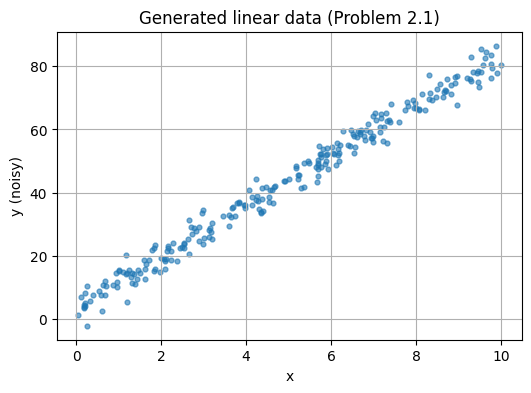

In [ ]:
# Problem 2.1 - Generate Your Own Data

import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
torch.manual_seed(0)
np.random.seed(0)


a_true = 8.0           # slope
b_true = 4.0           # intercept
sigma_epsilon = 3.0    # noise std

N = 250
X_np = np.random.uniform(0, 10, N)                        # sample x_n in [0,10]
y_np = a_true * X_np + b_true + sigma_epsilon * np.random.randn(N)  # linear + noise

# Convert shapes: each row is one observation (N x 1)
X = torch.tensor(X_np).reshape(N, 1).float()   # shape (N,1)
y = torch.tensor(y_np).reshape(N, 1).float()   # shape (N,1)

# Plot of the data
plt.figure(figsize=(6,4))
plt.scatter(X_np, y_np, alpha=0.6, s=12)
plt.xlabel('x')
plt.ylabel('y (noisy)')
plt.title('Generated linear data (Problem 2.1)')
plt.grid(True)
plt.show()

**Problem 2.2 - Make a PyTorch dataset object "TensorDataset"**

In [ ]:
batch_size = 13
train_dataset = TensorDataset(X, y)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Using batch_size={batch_size}, number of mini-batches per epoch={int(np.ceil(N/batch_size))}")

Using batch_size=13, number of mini-batches per epoch=20


**Problem 2.3 — Create a One-Dimensional Linear Predictive Model**

Now create the following linear prediction model:

$$
y(x, \mathbf{w}) = y(x, [w_0, w_1]) = w_0 + w_1 x
$$

in your code.

In [ ]:
model = nn.Sequential(nn.Linear(in_features=1, out_features=1))
print("Model structure:", model)

Model structure: Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
)


**Problem 2.4- Define cost function**

In [ ]:
# MSE is the usual loss function for least squares style problems
cost_function = nn.MSELoss()
print(f"Cost Function selected: {cost_function}")

Cost Function selected: MSELoss()


**Problem 2.5 - Choose optimizer and learning rate**

In [ ]:
learning_rate = 1e-3
optim = torch.optim.SGD(model.parameters(), lr=learning_rate) # Model.parameters automatically collects all weights and biases
print(f"Optimizer selected: {optim}")

Optimizer selected: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


**Problem 2.6- Train your model and plot training cost curve**

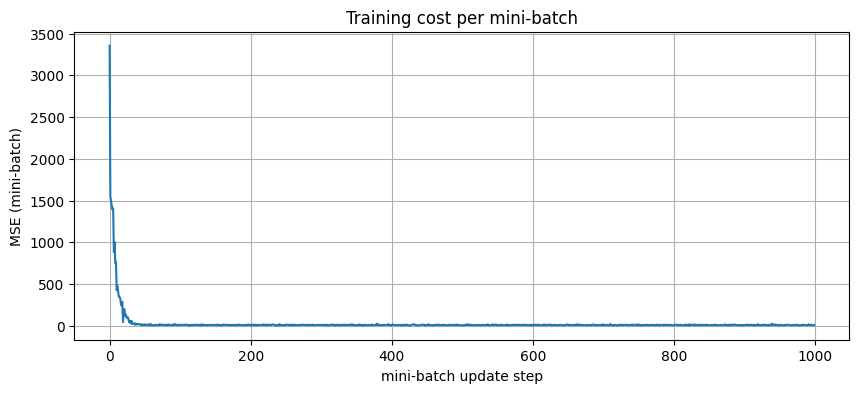

In [ ]:
# Train the model and store cost per mini-batch

training_minibatch_Js = []
nr_epochs = 50

for epoch in range(nr_epochs):
    for X_batch, y_batch in train_loader:
        y_preds = model(X_batch)                 # forward pass
        cost = cost_function(y_preds, y_batch)   # compute mini-batch MSE
        optim.zero_grad()                        # zero gradients
        cost.backward()                          # backprop to compute gradients
        optim.step()                             # update parameters
        training_minibatch_Js.append(cost.item())

# plot cost over updates
plt.figure(figsize=(10,4))
plt.plot(training_minibatch_Js)
plt.xlabel('mini-batch update step')
plt.ylabel('MSE (mini-batch)')
plt.title('Training cost per mini-batch')
plt.grid(True)
plt.show()

 **Problem 2.7- Make predictions**



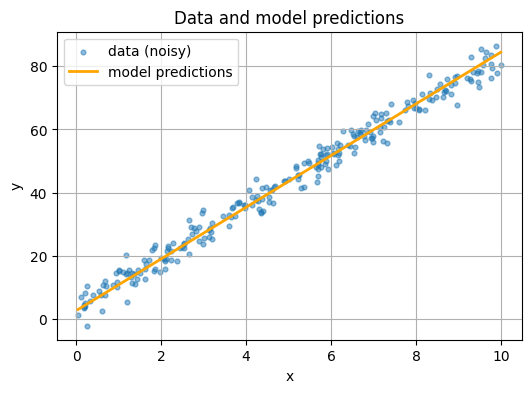

In [ ]:
with torch.no_grad():
    y_preds_all = model(X)     # predict for all training inputs

# plot data points and fitted line (or predictions)
plt.figure(figsize=(6,4))
plt.scatter(X_np, y_np, alpha=0.5, s=12, label='data (noisy)')
# For a linear model we can plot the fitted line by sorting X
xs_sorted, indices = torch.sort(X.squeeze())
ys_sorted = y_preds_all[indices].numpy().squeeze()
plt.plot(xs_sorted.numpy(), ys_sorted, color='orange', linewidth=2, label='model predictions')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Data and model predictions')
plt.legend(); plt.grid(True)
plt.show()

**Problem 2.8 - Print and look at your final model parameters**

In [ ]:
for name, param in model.named_parameters():
    print(name, param.data.numpy().reshape(-1))

# Compare to true values a_true (slope) and b_true (intercept)
w1 = list(model.parameters())[0].data.numpy().squeeze()  # weight
w0 = list(model.parameters())[1].data.numpy().squeeze()  # bias
print(f"\nFitted w1 (slope) = {w1}, fitted w0 (intercept) = {w0}")
print(f"True a_true = {a_true}, true b_true = {b_true}")


0.weight [8.196451]
0.bias [2.5891974]

Fitted w1 (slope) = 8.196451187133789, fitted w0 (intercept) = 2.5891973972320557
True a_true = 8.0, true b_true = 4.0


## Problem 3.1 — A Single Artificial Neuron

**(a)** Make a plot using Python that shows the four activation functions:

$$
\phi(v) = \frac{1}{1 + e^{-v}}, \quad
\phi(v) = \max\{0, v\}, \quad
\phi(v) = \tanh(v), \quad
\phi(v) = v
$$
on the interval **[-5, 5]**.


**(b)** An artificial neuron with only one input value \(x\) has two adjustable parameters.  Which are they?

**(c)** How many adjustable parameters does a single neuron have when its input is a  \(d\)-dimensional input vector:

$$
x = [x_1, x_2, \ldots, x_d]^T
$$

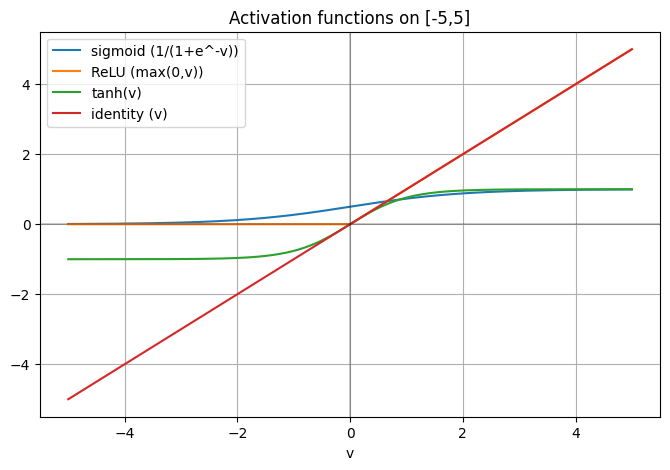

In [ ]:
# (a) Plot the four activations

import numpy as np
import matplotlib.pyplot as plt

v = np.linspace(-5, 5, 401)
sigmoid = 1 / (1 + np.exp(-v))
relu = np.maximum(0, v)
tanh = np.tanh(v)
identity = v

plt.figure(figsize=(8,5))
plt.plot(v, sigmoid, label='sigmoid (1/(1+e^-v))')
plt.plot(v, relu, label='ReLU (max(0,v))')
plt.plot(v, tanh, label='tanh(v)')
plt.plot(v, identity, label='identity (v)')
plt.axhline(0, color='k', linewidth=.3)
plt.axvline(0, color='k', linewidth=.3)
plt.legend(); plt.grid(True)
plt.xlabel('v'); plt.title('Activation functions on [-5,5]')
plt.show()

(b) One-input neuron; two adjustable parameters

If $d=1$, the neuron computes:
$$
v = w_0 + w_1 x, \quad y = \phi(v).
$$

Adjustable parameters:

$w_1$ - the weight (how $x$ scales the output)

$w_0$ - the bias/intercept (shifts the function vertically)

**So two tunable parameters.**

(c) d-dimensional input; number of adjustable parameters

For inputs $x_1, \dots, x_d$:
$$
v = w_0 + \sum_{i=1}^d w_i x_i.
$$

Tunable parameters: weights $w_1, \dots, w_d$ ($d$ parameters) plus bias $w_0$ ($1$ parameter) $;$ total $d+1$ parameters.

**Problem 3.2: Number of tunable parameters in Multilayer FANN**


Consider a fully connected layer that maps from $n_{\text{in}}$ inputs to $n_{\text{out}}$ outputs (neurons). Each output neuron has:

$n_{\text{in}}$ weights (one per input)

$1$ bias

So parameters in that layer $= n_{\text{out}} \times (n_{\text{in}} + 1)$.

For a network with multiple layers, sum this across layers. If layers are indexed $L=1..M$ and:

$n^{(0)}$ = number of inputs (I)

$n^{(1)}$ = size of first hidden layer (H1)

$\dots$

$n^{(M)}$ = size of last hidden layer (HM)

$n^{(M+1)}$ = number of outputs (O)

Then total tunable parameters $P$ is:
$$
P = \sum_{k=1}^{M+1} n^{(k)} (n^{(k-1)} + 1)
$$
where each term = (\#neurons in layer $k$) $\times$ (inputs to that layer $+ 1$ bias).

**Problem 3.3: Mathematical expression for a Multilayer FANN outpu**

Setting : two inputs $(x_1, x_2)$. Two hidden layers. The weights are named:

first hidden layer: weights $u_{j,i}$ from input $i$ to neuron $j$, bias $u_{j,0}$

second hidden layer: weights $v_{k,j}$ from outputs of first hidden layer to neuron $k$, bias $v_{k,0}$

output layer: weights $w_{\text{out}, k}$ from second hidden layer outputs to output neuron, bias $w_{\text{out}, 0}$

Assume the first hidden layer has $J$ neurons, second has $K$ neurons, and final output is scalar. Activation everywhere is $\phi(\cdot)$ for simplicity.

Step-by-step expression

First hidden layer outputs --- for each $j=1, \dots, J$:
$$
h_j(x_1, x_2) = \phi(u_{j,0} + u_{j,1} x_1 + u_{j,2} x_2).
$$

Second hidden layer outputs --- for each $k=1, \dots, K$:
$$
z_k(x_1, x_2) = \phi \left( v_{k,0} + \sum_{j=1}^{J} v_{k,j} h_j(x_1, x_2) \right) = \phi \left( v_{k,0} + \sum_{j=1}^{J} v_{k,j} \phi(u_{j,0} + u_{j,1} x_1 + u_{j,2} x_2) \right).
$$

Output (single neuron):
$$
\hat{y}(x_1, x_2) = \phi \left( w_{\text{out}, 0} + \sum_{k=1}^{K} w_{\text{out}, k} z_k(x_1, x_2) \right).
$$

Combine: substitute $z_k$:
$$
\hat{y}(x_1, x_2) = \phi \left( w_{\text{out}, 0} + \sum_{k=1}^{K} w_{\text{out}, k} \phi \left( v_{k,0} + \sum_{j=1}^{J} v_{k,j} \phi(u_{j,0} + u_{j,1} x_1 + u_{j,2} x_2) \right) \right).
$$

**Problem 3.4: Interpretability of MSE vs RMSE**

Given: $y_n$ has unit kg.

MSE is defined as $\text{MSE} = \frac{1}{N} \sum (y_n - \hat{y}_n)^2$. If $y_n$ is in kg, each squared term $(y_n - \hat{y}_n)^2$ has units $\text{kg}^2$. Thus MSE unit $= \text{kg}^2$.

RMSE is $\sqrt{\text{MSE}}$. Taking square root yields unit kg again

Given:

$N = 64 \cdot 10^6$ training examples (i.e., $64 \times 10^6$).
Mini-batch size $= 64$.

Compute mini-batches per epoch
$$
\text{mini-batches per epoch} = \frac{N}{\text{batch size}} = \frac{64 \cdot 10^6}{64} = 10^6.
$$

So one epoch $= 1,000,000$ updates (if you update per mini-batch).

After 3 epochs:

Full-batch (conventional) Gradient Descent: updates per epoch $= 1$ (compute gradient on full dataset and update once). After 3 epochs $\rightarrow 3$ updates.

SGD with mini-batches: updates per epoch $= 1,000,000$. After 3 epochs $\rightarrow 3 \times 10^6$ updates.

Why this suggests SGD is more attractive:



*   With SGD you get many more parameterupdates early, so the model can make many small improvements quickly rather than waiting for full passes.
*   Mini-batch updates require much less memory (only one batch in memory), and are much faster per update (so you can iterate more).
*   The statistical efficiency: multiple noisy updates help exploration and often converge faster in wall-clock time.

**Problem 3.6: Reduced problems with local minima**

Why does (deterministic) Gradient Descent suffer with many shallow local minima?

Gradient Descent moves deterministically in the negative gradient direction of the global loss $J(\theta)$ (computed over all training data).

If the loss surface contains many shallow local minima or very flat regions, pure gradient descent can get trapped: once in a basin of attraction, gradients point toward that local minimum and the algorithm converges there (unless the step size is large enough to jump out, which risks instability).

Why does SGD reduce the risk of getting stuck?

SGD uses approximate gradients computed on random mini-batches. Each mini-batch gradient is a noisy estimate of the true gradient. This noise has two useful effects:

Exploration: the noise can push the iterate out of small local basins; even when the true gradient would point into the basin, a noisy estimate may point a slightly different direction allowing escape.

Avoiding unnecessary precision: SGD does not commit to the exact local curvature, it tends to wander and then settle near wide minima, which often generalize better.


**Task B: Non-linear univariate regression using FANNs**

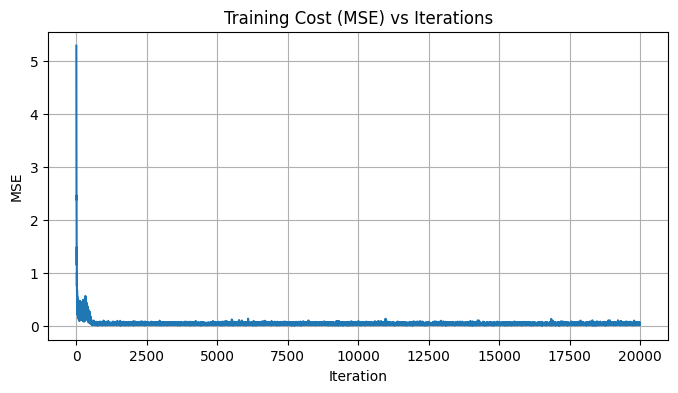

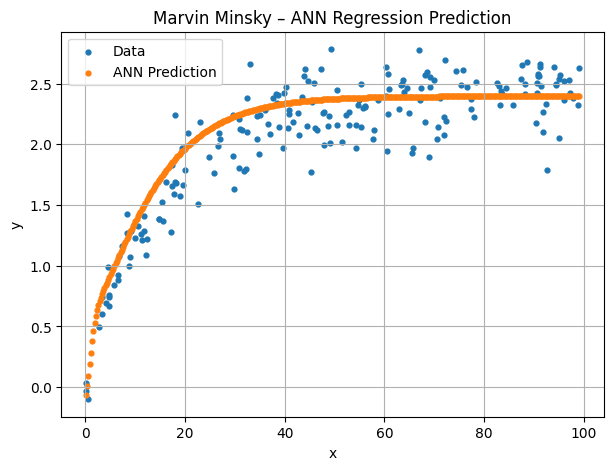

Final MSE: 0.050282545387744904


In [ ]:
from numpy import genfromtxt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

file_path = "dataset_Marvin_Minsky.csv"

# Load CSV
my_data = genfromtxt(file_path, delimiter=",", skip_header=1)

# Convert to tensors
X = torch.tensor(my_data[:, 0]).reshape(-1, 1).float()
y_obs = torch.tensor(my_data[:, 1]).reshape(-1, 1).float()

# Dataset + DataLoader
my_dataset = TensorDataset(X, y_obs)
my_dataloader = DataLoader(my_dataset, batch_size=20, shuffle=True)

# Defining the 1-3-3-1 ANN

model = nn.Sequential(
    nn.Linear(1, 3),
    nn.Tanh(),
    nn.Linear(3, 3),
    nn.Tanh(),
    nn.Linear(3, 1)
)

# Cost function and optimizer

cost_function = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Train the network (mini-batch SGD)

nr_epochs = 2000
training_costs = []

for epoch in range(nr_epochs):
    for X_batch, y_batch in my_dataloader:

        # Forward pass
        y_pred = model(X_batch)

        # Cost
        cost = cost_function(y_pred, y_batch)

        # Backprop
        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        # Track training cost
        training_costs.append(cost.item())

# Plotting the training cost

plt.figure(figsize=(8,4))
plt.plot(training_costs)
plt.title("Training Cost (MSE) vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# plotting prediction curve Vs true data

model.eval()
with torch.no_grad():
    # convert tensor to float
    x_plot = np.linspace(X.min().item(), X.max().item(), 400).astype("float32")
    x_plot_t = torch.tensor(x_plot).reshape(-1,1)
    y_plot = model(x_plot_t).numpy()

plt.figure(figsize=(7,5))
plt.scatter(X.numpy(), y_obs.numpy(), s=12, label="Data")
plt.scatter(x_plot, y_plot, s=12, label="ANN Prediction")
plt.title("Marvin Minsky – ANN Regression Prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


# Final MSE  which should be below 0.1

model.eval()
with torch.no_grad():
    final_mse = cost_function(model(X), y_obs).item()

print("Final MSE:", final_mse)


**Task C: Approximate a bell-shaped bivariate function**

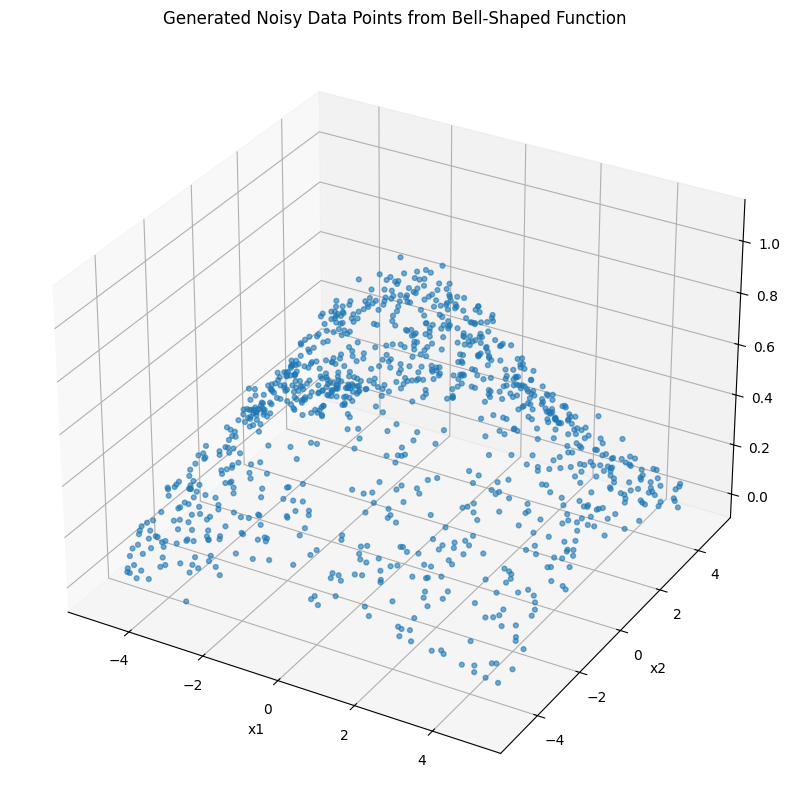

Dataset size: 1000
Batch size: 13
Number of batches per epoch: 77
Architecture I: 2-40-1
Sequential(
  (0): Linear(in_features=2, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=1, bias=True)
)

Architecture II: 2-40-40-40-1
Sequential(
  (0): Linear(in_features=2, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=40, bias=True)
  (5): ReLU()
  (6): Linear(in_features=40, out_features=1, bias=True)
)


Training Architecture I (2-40-1)


Epoch 50/400, Cost: 0.002334
Epoch 100/400, Cost: 0.001278
Epoch 150/400, Cost: 0.004280
Epoch 200/400, Cost: 0.002430
Epoch 250/400, Cost: 0.001021
Epoch 300/400, Cost: 0.002129
Epoch 350/400, Cost: 0.001331
Epoch 400/400, Cost: 0.001973


Training Architecture II (2-40-40-40-1)


Epoch 50/400, Cost: 0.001350
Epoch 100/400, Cost: 0.000974
Epoch 150/400, Cost: 0.001496
Epoch 200/400, Cost: 0.000815
Epoch 250/400

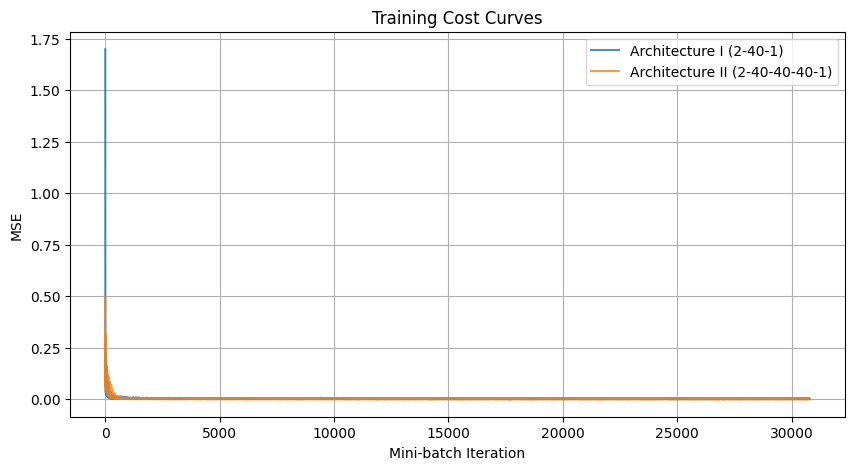



FINAL RESULTS


Architecture I  - Learning rate: 0.01
Architecture I  - Final MSE: 0.001846

Architecture II - Learning rate: 0.01
Architecture II - Final MSE: 0.001465


3D SURFACE VISUALIZATION - ARCHITECTURE I




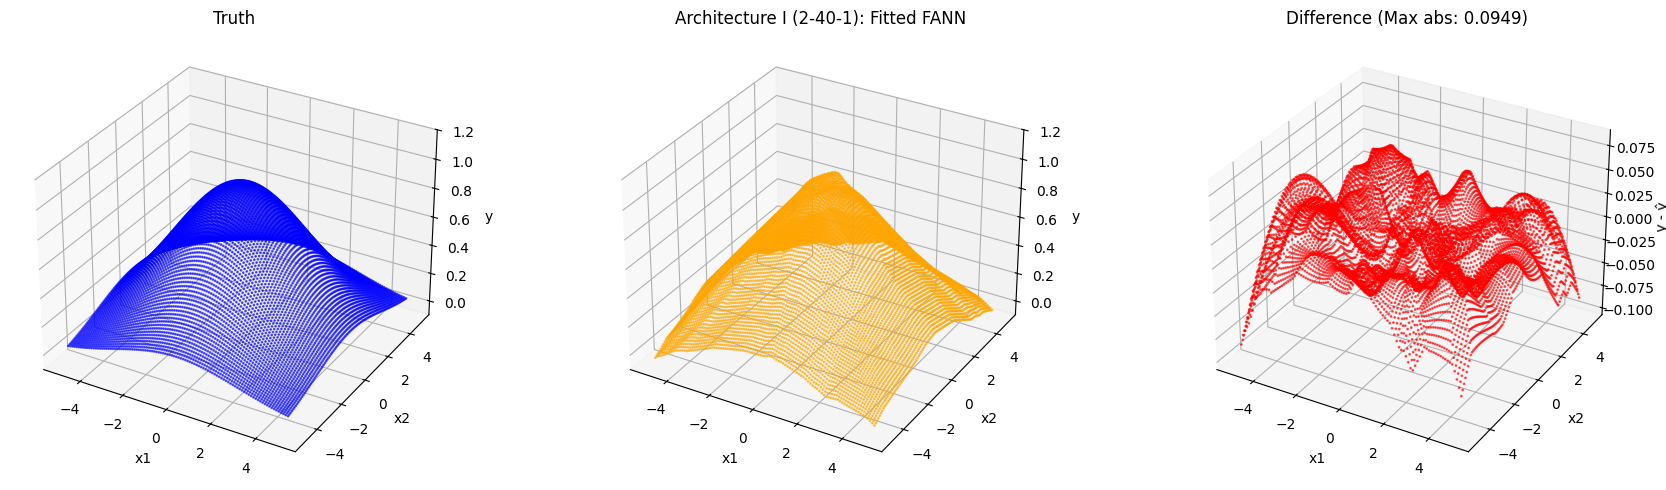


Architecture I (2-40-1) - Max absolute error: 0.094922


3D SURFACE VISUALIZATION - ARCHITECTURE II




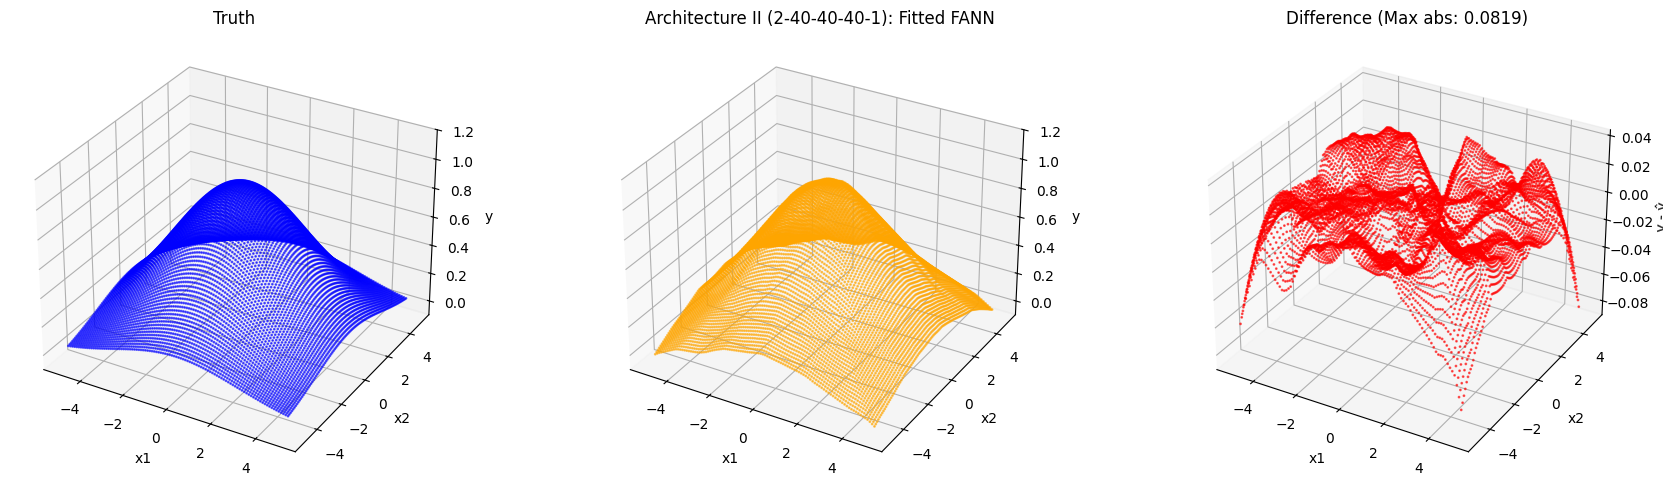


Architecture II (2-40-40-40-1) - Max absolute error: 0.081911


np.float64(0.08191129122838789)

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# (a) Generate N=1000 noisy data-points

N = 1000  # Number of data points
sigma_noise = 0.04

# Generate x coordinates: uniformly from [-5, 5] x [-5, 5]
x_np = 10 * np.random.rand(N, 2) - 5  # NumPy array shape (N, 2)

# Generate y values using the bell-shaped function
mean_true_np = np.array([0.0, 0.0])
y_np = np.zeros(N)

for i in range(N):
    diff = x_np[i, :] - mean_true_np
    y_np[i] = np.exp(-(diff @ diff) / 16) + sigma_noise * np.random.randn()

# Convert to PyTorch tensors with proper shapes
x = torch.tensor(x_np).reshape(N, 2).float()  # shape (N, 2)
y = torch.tensor(y_np).reshape(N, 1).float()  # shape (N, 1)

# Plotting the generated data
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d')
ax.scatter(x_np[:, 0], x_np[:, 1], y_np, alpha=0.6, s=12)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('Generated Noisy Data Points from Bell-Shaped Function')
plt.show()

# Creatting dataset and dataloader
my_dataset = TensorDataset(x, y)
batch_size = 13
my_dataloader = DataLoader(my_dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset size: {N}")
print(f"Batch size: {batch_size}")
print(f"Number of batches per epoch: {len(my_dataloader)}")

# Part (b) Defining Architecture I (2-40-1, ReLU) and Architecture II (2-40-40-40-1, ReLU)
# Architecture I (2-40-1, ReLU)
model_I = nn.Sequential(
    nn.Linear(2, 40),
    nn.ReLU(),
    nn.Linear(40, 1)
)

print("Architecture I: 2-40-1")
print(model_I)

# Architecture II (2-40-40-40-1, ReLU)
model_II = nn.Sequential(
    nn.Linear(2, 40),
    nn.ReLU(),
    nn.Linear(40, 40),
    nn.ReLU(),
    nn.Linear(40, 40),
    nn.ReLU(),
    nn.Linear(40, 1)
)

print("\nArchitecture II: 2-40-40-40-1")
print(model_II)

# Part (c) Training Function

def train_model(model, dataloader, lr=0.01, epochs=400):
    """Train model using mini-batch SGD"""
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    cost_history = []

    for epoch in range(epochs):
        for X_batch, y_batch in dataloader:
            # Forward pass
            preds = model(X_batch)
            cost = loss_fn(preds, y_batch)

            # Backward pass
            optimizer.zero_grad()
            cost.backward()
            optimizer.step()

            cost_history.append(cost.item())

        # Print progress every 50 epochs
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Cost: {cost.item():.6f}")

    return cost_history

# Part (C) Train Both Models
print("\n")
print("Training Architecture I (2-40-1)")
print("\n")
cost_I = train_model(model_I, my_dataloader, lr=0.01, epochs=400)

print("\n")
print("Training Architecture II (2-40-40-40-1)")
print("\n")
cost_II = train_model(model_II, my_dataloader, lr=0.01, epochs=400)

# Part (d.2) Plot Training Cost Curves

plt.figure(figsize=(10, 5))
plt.plot(cost_I, label="Architecture I (2-40-1)", alpha=0.8)
plt.plot(cost_II, label="Architecture II (2-40-40-40-1)", alpha=0.8)
plt.xlabel("Mini-batch Iteration")
plt.ylabel("MSE")
plt.title("Training Cost Curves")
plt.legend()
plt.grid(True)
plt.show()

# Part (d.3) Final Cost Values

loss_fn = nn.MSELoss()

model_I.eval()
model_II.eval()

with torch.no_grad():
    final_cost_I = loss_fn(model_I(x), y).item()
    final_cost_II = loss_fn(model_II(x), y).item()

print("\n")
print("FINAL RESULTS")
print("\n")
print(f"Architecture I  - Learning rate: 0.01")
print(f"Architecture I  - Final MSE: {final_cost_I:.6f}")
print(f"\nArchitecture II - Learning rate: 0.01")
print(f"Architecture II - Final MSE: {final_cost_II:.6f}")

# Generate Surface Comparison Plots (Part d.4)

def plot_surface_comparison(model, model_name):
    """Create 3D surface plots comparing true function, fitted FANN, and difference"""

    # Generate grid
    x1 = np.linspace(-5, 5, 100)
    x2 = np.linspace(-5, 5, 100)
    X_grid, Y_grid = np.meshgrid(x1, x2)

    # Flatten grid
    s_np = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
    n_points = len(s_np)
    s = torch.tensor(s_np).reshape(n_points, 2).float()

    # True surface
    y_true_np = np.zeros(n_points)
    for i in range(n_points):
        diff = s_np[i, :] - mean_true_np
        y_true_np[i] = np.exp(-(diff @ diff) / 16)

    # Predicted surface
    model.eval()
    with torch.no_grad():
        y_preds = model(s).numpy().flatten()

    # 3D Surface plots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, subplot_kw={'projection': '3d'},
                                         figsize=(18, 5))

    # Truth
    ax1.scatter(s_np[:, 0], s_np[:, 1], y_true_np, c='blue', alpha=0.6, s=1)
    ax1.set_title("Truth")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    ax1.set_zlabel("y")
    ax1.set_zlim(-0.1, 1.2)

    # Fitted FANN
    ax2.scatter(s_np[:, 0], s_np[:, 1], y_preds, c='orange', alpha=0.6, s=1)
    ax2.set_title(f"{model_name}: Fitted FANN")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    ax2.set_zlabel("y")
    ax2.set_zlim(-0.1, 1.2)

    # Difference
    diff = y_preds - y_true_np
    max_abs_diff = np.max(np.abs(diff))
    ax3.scatter(s_np[:, 0], s_np[:, 1], diff, c='red', alpha=0.6, s=1)
    ax3.set_title(f"Difference (Max abs: {max_abs_diff:.4f})")
    ax3.set_xlabel("x1")
    ax3.set_ylabel("x2")
    ax3.set_zlabel("y - ŷ")

    plt.tight_layout()
    plt.show()

    print(f"\n{model_name} - Max absolute error: {max_abs_diff:.6f}")

    return max_abs_diff

# Plot for Architecture I
print("\n")
print("3D SURFACE VISUALIZATION - ARCHITECTURE I")
print("\n")
plot_surface_comparison(model_I, "Architecture I (2-40-1)")

# Plot for Architecture II
print("\n")
print("3D SURFACE VISUALIZATION - ARCHITECTURE II")
print("\n")
plot_surface_comparison(model_II, "Architecture II (2-40-40-40-1)")



**Task D: Model Selection Using a Validation Set**



TASK D - PART (a): Validation Set Comparison



Generated 5 validation examples
Validation set shape: x=torch.Size([5, 2]), y=torch.Size([5, 1])

Validation Set Performance:
Architecture I  (2-40-1):       RMSE = 0.040815
Architecture II (2-40-40-40-1): RMSE = 0.033321


SELECTED MODEL: Architecture II (2-40-40-40-1)




TASK D - PART (b): True Performance Estimation



Generating 25000 test examples...

True Performance Estimate (N = 25000):
Architecture II (2-40-40-40-1): RMSE = 0.041739

Comparison:
Validation estimate (N=5):     RMSE = 0.033321
True estimate (N=25000):    RMSE = 0.041739
Difference:                     0.008418


WHY 25,000 EXAMPLES GIVES NEAR-TRUE PERFORMANCE:



The RMSE calculated using 25,000 independent test examples gives a value
very close to the true (unknown) RMSE because:

1. LAW OF LARGE NUMBERS: With 25,000 samples, the sample mean squared
   error converges to the expected (true) mean squared error.

2. LOW VARIANCE: The standard error of the mean de

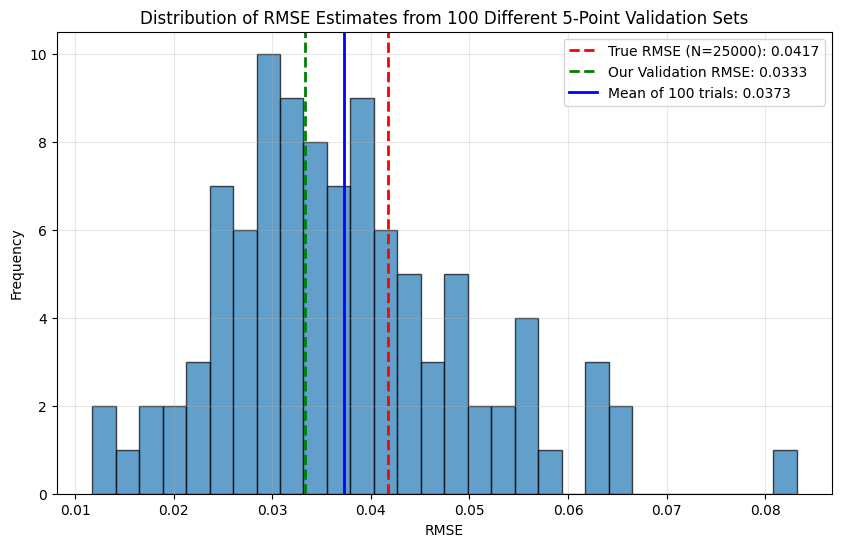


Statistics from 100 trials:
Mean RMSE:   0.037317
Std Dev:     0.012590
Min RMSE:    0.011721
Max RMSE:    0.083195
True RMSE:   0.041739


TASK D - PART (d): Performance of Rejected Model



Rejected Model: Architecture I (2-40-1)
Validation RMSE (N=5):          0.040815
True RMSE (N=25000):          0.045744


FINAL COMPARISON - TRUE PERFORMANCE



Architecture II (2-40-40-40-1):
  Validation RMSE: 0.033321
  True RMSE:       0.041739
  Status:          SELECTED based on validation

Architecture I (2-40-1):
  Validation RMSE: 0.040815
  True RMSE:       0.045744
  Status:          REJECTED based on validation


✓ CORRECT DECISION: The selected model is actually better!
  Improvement: 0.004005

True performance difference: 0.004005


CREATING SUMMARY VISUALIZATION




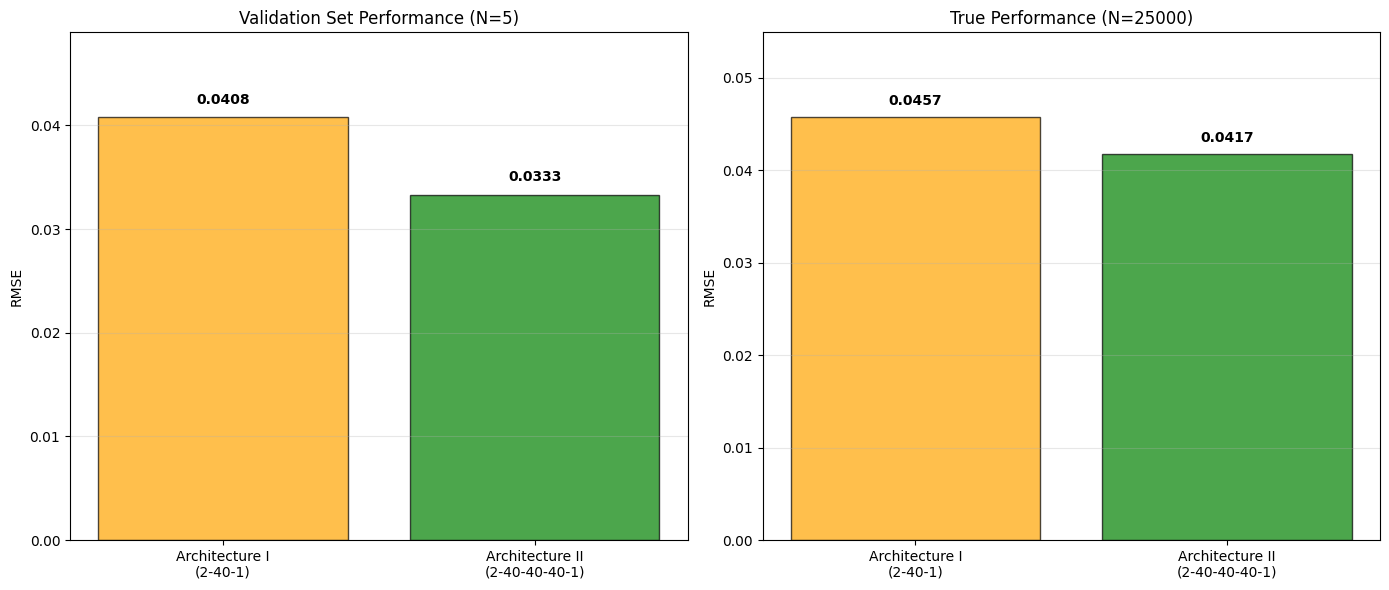

In [3]:


import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

# We used the same random seed for reproducibility here
np.random.seed(123)
torch.manual_seed(123)

# Helper Function: Generate Test Data
# This creates new test/validation samples drawn from the true bell-shaped function.
def generate_test_data(N_test, sigma_noise=0.04):
    """
    Generate test data from the bell-shaped function

    Args:
        N_test: Number of test examples
        sigma_noise: Standard deviation of additive noise

    Returns:
        x_test: Input tensor (N_test, 2)
        y_test: Output tensor (N_test, 1)
    """
    # Generates random x coordinates
    x_test_np = 10 * np.random.rand(N_test, 2) - 5
    # Stores the center of the bell
    mean_true_np = np.array([0.0, 0.0])

    # Generate y values
    y_test_np = np.zeros(N_test)
    for i in range(N_test):
        diff = x_test_np[i, :] - mean_true_np
        y_test_np[i] = np.exp(-(diff @ diff) / 16) + sigma_noise * np.random.randn()
        # diff @ diff is the dot product which gives as x1^2 + X2^2
        # this creates a bell shaped curve
    # Convert to PyTorch tensors
    x_test = torch.tensor(x_test_np).reshape(N_test, 2).float()
    y_test = torch.tensor(y_test_np).reshape(N_test, 1).float()

    return x_test, y_test

# Helper Function: Calculate RMSE
# Given a trained model, compute its Root Mean Squared Error
def calculate_rmse(model, x_test, y_test):
    """
    Calculate Root Mean Squared Error for a model on test data

    Args:
        model: Trained PyTorch model
        x_test: Input tensor
        y_test: True output tensor

    Returns:
        rmse: Root Mean Squared Error
    """
    model.eval() # we put a model in evaluation mode
    with torch.no_grad(): # Disable gradients
        y_pred = model(x_test) # Compute predictions
        mse = nn.MSELoss()(y_pred, y_test).item() # compute MSE
        rmse = np.sqrt(mse) # Compute RMSE
    return rmse

# Part (a): Generate 5 Validation Examples and Compare Models

print("\n")
print("TASK D - PART (a): Validation Set Comparison")
print("\n")

N_val = 5

# Generate small validation set
x_val, y_val = generate_test_data(N_val)

print(f"\nGenerated {N_val} validation examples")
print(f"Validation set shape: x={x_val.shape}, y={y_val.shape}")

# Calculate RMSE for both models
rmse_I_val = calculate_rmse(model_I, x_val, y_val)
rmse_II_val = calculate_rmse(model_II, x_val, y_val)

print(f"\nValidation Set Performance:")
print(f"Architecture I  (2-40-1):       RMSE = {rmse_I_val:.6f}")
print(f"Architecture II (2-40-40-40-1): RMSE = {rmse_II_val:.6f}")

# Determine which model is better
if rmse_I_val < rmse_II_val:
    selected_model = model_I
    selected_name = "Architecture I (2-40-1)"
    selected_rmse_val = rmse_I_val
    rejected_model = model_II
    rejected_name = "Architecture II (2-40-40-40-1)"
    rejected_rmse_val = rmse_II_val
else:
    selected_model = model_II
    selected_name = "Architecture II (2-40-40-40-1)"
    selected_rmse_val = rmse_II_val
    rejected_model = model_I
    rejected_name = "Architecture I (2-40-1)"
    rejected_rmse_val = rmse_I_val

print("\n")
print(f"SELECTED MODEL: {selected_name}")
print("\n")


# Part (b): Estimate True Performance with 25,000 Test Examples

print("\n")
print("TASK D - PART (b): True Performance Estimation")
print("\n")

N_BIG_TEST = 25000

# Generate large test set
print(f"\nGenerating {N_BIG_TEST} test examples...")
x_big_test, y_big_test = generate_test_data(N_BIG_TEST)

# Calculate RMSE on large test set for selected model
rmse_selected_true = calculate_rmse(selected_model, x_big_test, y_big_test)

print(f"\nTrue Performance Estimate (N = {N_BIG_TEST}):")
print(f"{selected_name}: RMSE = {rmse_selected_true:.6f}")

print(f"\nComparison:")
print(f"Validation estimate (N=5):     RMSE = {selected_rmse_val:.6f}")
print(f"True estimate (N={N_BIG_TEST}):    RMSE = {rmse_selected_true:.6f}")
print(f"Difference:                     {abs(selected_rmse_val - rmse_selected_true):.6f}")

# Explanation
print("\n")
print("WHY 25,000 EXAMPLES GIVES NEAR-TRUE PERFORMANCE:")
print("\n")
print("""
The RMSE calculated using 25,000 independent test examples gives a value
very close to the true (unknown) RMSE because:

1. Large test size: With 25,000 samples, the sample mean squared
   error converges to the expected (true) mean squared error.

2. LOW VARIANCE: The standard error of the mean decreases as 1/√N.
   With N=25,000, the standard error is ~1/158 of the standard deviation,
   making the estimate very stable.

3. INDEPENDENCE: These are new, unseen examples generated from the same
   distribution, so they represent the true population the model will
   encounter in practice.

4. REPRESENTATIVE SAMPLE: 25,000 examples thoroughly cover the input
   space [-5,5] × [-5,5], ensuring all regions are well-represented.
""")

# Part (c): Compare Validation vs True Performance

print("\n")
print("TASK D - PART (c): Validation vs True Performance Analysis")
print("\n")

# Calculate difference and percentage
difference = selected_rmse_val - rmse_selected_true
percent_diff = (difference / rmse_selected_true) * 100

print(f"\nPerformance Comparison:")
print(f"Validation RMSE (N=5):          {selected_rmse_val:.6f}")
print(f"True RMSE (N={N_BIG_TEST}):          {rmse_selected_true:.6f}")
print(f"Difference:                     {difference:.6f}")
print(f"Percentage difference:          {percent_diff:.2f}%")

if difference > 0:
    print(f"\n→ The validation estimate is OPTIMISTIC (underestimates error)")
elif difference < 0:
    print(f"\n→ The validation estimate is PESSIMISTIC (overestimates error)")
else:
    print(f"\n→ The validation estimate is exactly correct (unlikely!)")

print("\n")
print("ANALYSIS:")
print("\n")
print(f"""
With only 5 validation examples, the performance estimate has:

1. HIGH VARIANCE: Small sample size leads to unreliable estimates
2. RANDOM FLUCTUATION: The estimate can be much better or worse than truth
3. POOR COVERAGE: 5 points don't adequately represent the entire domain

RECOMMENDATION: YES, more validation examples are needed!
- Typical practice: Use 10-20% of data for validation
- For this problem: 100-200 examples would be more appropriate
- This would give more reliable model selection decisions
""")

# Visualize the uncertainty
print("\nDemonstrating validation set variability...")
print("Generating 100 different 5-point validation sets:")

# Generate multiple validation sets to show variability
n_trials = 100
rmse_trials = []

for trial in range(n_trials):
    x_val_trial, y_val_trial = generate_test_data(5)
    rmse_trial = calculate_rmse(selected_model, x_val_trial, y_val_trial)
    rmse_trials.append(rmse_trial)

rmse_trials = np.array(rmse_trials)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(rmse_trials, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(rmse_selected_true, color='red', linestyle='--', linewidth=2,
            label=f'True RMSE (N=25000): {rmse_selected_true:.4f}')
plt.axvline(selected_rmse_val, color='green', linestyle='--', linewidth=2,
            label=f'Our Validation RMSE: {selected_rmse_val:.4f}')
plt.axvline(np.mean(rmse_trials), color='blue', linestyle='-', linewidth=2,
            label=f'Mean of 100 trials: {np.mean(rmse_trials):.4f}')
plt.xlabel('RMSE')
plt.ylabel('Frequency')
plt.title('Distribution of RMSE Estimates from 100 Different 5-Point Validation Sets')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nStatistics from 100 trials:")
print(f"Mean RMSE:   {np.mean(rmse_trials):.6f}")
print(f"Std Dev:     {np.std(rmse_trials):.6f}")
print(f"Min RMSE:    {np.min(rmse_trials):.6f}")
print(f"Max RMSE:    {np.max(rmse_trials):.6f}")
print(f"True RMSE:   {rmse_selected_true:.6f}")

# Part (d): True Performance of Rejected Model

print("\n")
print("TASK D - PART (d): Performance of Rejected Model")
print("\n")

# Calculate true performance of rejected model
rmse_rejected_true = calculate_rmse(rejected_model, x_big_test, y_big_test)

print(f"\nRejected Model: {rejected_name}")
print(f"Validation RMSE (N=5):          {rejected_rmse_val:.6f}")
print(f"True RMSE (N={N_BIG_TEST}):          {rmse_rejected_true:.6f}")

print("\n")
print("FINAL COMPARISON - TRUE PERFORMANCE")
print("\n")
print(f"\n{selected_name}:")
print(f"  Validation RMSE: {selected_rmse_val:.6f}")
print(f"  True RMSE:       {rmse_selected_true:.6f}")
print(f"  Status:          SELECTED based on validation")

print(f"\n{rejected_name}:")
print(f"  Validation RMSE: {rejected_rmse_val:.6f}")
print(f"  True RMSE:       {rmse_rejected_true:.6f}")
print(f"  Status:          REJECTED based on validation")

print("\n")
if rmse_selected_true < rmse_rejected_true:
    print("✓ CORRECT DECISION: The selected model is actually better!")
    print(f"  Improvement: {(rmse_rejected_true - rmse_selected_true):.6f}")
else:
    print("✗ WRONG DECISION: The rejected model is actually better!")
    print(f"  We missed improvement of: {(rmse_selected_true - rmse_rejected_true):.6f}")
    print(f"  This happened because validation set (N=5) was too small!")

print(f"\nTrue performance difference: {abs(rmse_selected_true - rmse_rejected_true):.6f}")

# Summary Visualization

print("\n")
print("CREATING SUMMARY VISUALIZATION")
print("\n")

# Create bar plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Validation comparison
models = ['Architecture I\n(2-40-1)', 'Architecture II\n(2-40-40-40-1)']
val_rmses = [rmse_I_val, rmse_II_val]
colors_val = ['green' if rmse_I_val < rmse_II_val else 'orange',
              'green' if rmse_II_val < rmse_I_val else 'orange']

ax1.bar(models, val_rmses, color=colors_val, alpha=0.7, edgecolor='black')
ax1.set_ylabel('RMSE')
ax1.set_title('Validation Set Performance (N=5)')
ax1.set_ylim(0, max(val_rmses) * 1.2)
ax1.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(val_rmses):
    ax1.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# True performance comparison
true_rmses = [rmse_selected_true if selected_model == model_I else rmse_rejected_true,
              rmse_selected_true if selected_model == model_II else rmse_rejected_true]
colors_true = ['green' if true_rmses[0] < true_rmses[1] else 'orange',
               'green' if true_rmses[1] < true_rmses[0] else 'orange']

ax2.bar(models, true_rmses, color=colors_true, alpha=0.7, edgecolor='black')
ax2.set_ylabel('RMSE')
ax2.set_title(f'True Performance (N={N_BIG_TEST})')
ax2.set_ylim(0, max(true_rmses) * 1.2)
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(true_rmses):
    ax2.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


**Task E: Early Stopping Using a Validation Set; Model (2-40-40-40-1)**

Dataset created:
Train: torch.Size([50, 2])
Val: torch.Size([25, 2])
Test: torch.Size([25, 2])
Epoch   1 | Validation RMSE = 0.298035
Epoch   2 | Validation RMSE = 0.288527
Epoch   3 | Validation RMSE = 0.219980
Epoch   4 | Validation RMSE = 0.202694
Epoch   5 | Validation RMSE = 0.146281
Epoch   6 | Validation RMSE = 0.091246
  OLD AVG: 0.268847 | NEW AVG: 0.146740
Epoch   7 | Validation RMSE = 0.110268
  OLD AVG: 0.237067 | NEW AVG: 0.115932
Epoch   8 | Validation RMSE = 0.105208
  OLD AVG: 0.189652 | NEW AVG: 0.102241
Epoch   9 | Validation RMSE = 0.103019
  OLD AVG: 0.146740 | NEW AVG: 0.106165
Epoch  10 | Validation RMSE = 0.083769
  OLD AVG: 0.115932 | NEW AVG: 0.097332
Epoch  11 | Validation RMSE = 0.106082
  OLD AVG: 0.102241 | NEW AVG: 0.097624
Epoch  12 | Validation RMSE = 0.119381
  OLD AVG: 0.106165 | NEW AVG: 0.103077
Epoch  13 | Validation RMSE = 0.075967
  OLD AVG: 0.097332 | NEW AVG: 0.100477

EARLY STOPPING TRIGGERED at epoch 13

Final Epoch Used: 13

Small Test Set RM

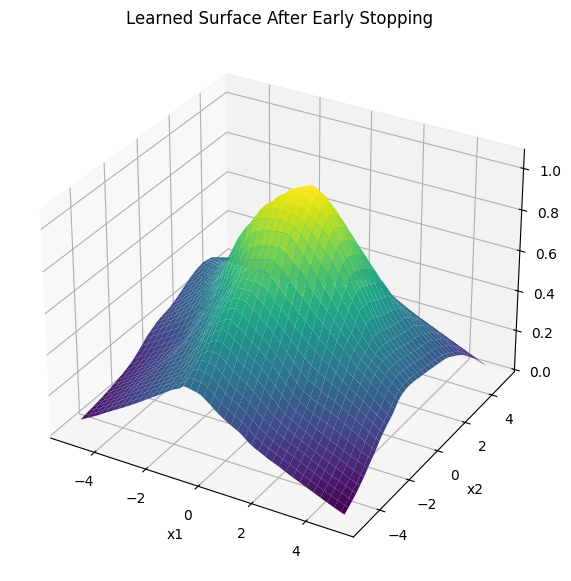


Comparison:
Test RMSE  (25 samples):     0.079669
True RMSE  (25,000 samples): 0.086120
Difference:                   0.006451


In [6]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt


# Helper: Generate bell-shaped synthetic data

def generate_data(N, sigma_noise=0.04):
    x = 10 * torch.rand(N, 2) - 5
    dist_sq = torch.sum(x**2, dim=1, keepdim=True)
    y = torch.exp(-dist_sq / 16) + sigma_noise * torch.randn(N, 1)
    return x.float(), y.float()

# Helper: Compute RMSE
def compute_rmse(model, X, Y):
    model.eval()
    with torch.no_grad():
        preds = model(X)
        mse = nn.MSELoss()(preds, Y).item()
    return np.sqrt(mse)

# Step 1: Create small dataset (100 examples)
N_total = 100
X_all, y_all = generate_data(N_total)

X_train = X_all[:50]
y_train = y_all[:50]

X_val = X_all[50:75]
y_val = y_all[50:75]

X_test_small = X_all[75:]
y_test_small = y_all[75:]

# Dataloader for training
batch_size = 10
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

print("Dataset created:")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test_small.shape)


# Step 2: Define large network (2-40-40-40-1)

model = nn.Sequential(
    nn.Linear(2, 40),
    nn.ReLU(),
    nn.Linear(40, 40),
    nn.ReLU(),
    nn.Linear(40, 40),
    nn.ReLU(),
    nn.Linear(40, 1)
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()


# Step 3: Early Stopping Training Loop


max_epochs = 200
val_rmses = []
stop_epoch = None

for epoch in range(max_epochs):

    #  Training
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    #  Validation
    rmse_val = compute_rmse(model, X_val, y_val)
    val_rmses.append(rmse_val)

    print(f"Epoch {epoch+1:3d} | Validation RMSE = {rmse_val:.6f}")

    #  Early Stopping Check after epoch 6
    if len(val_rmses) >= 6:
        old_avg = np.mean(val_rmses[-6:-3])
        new_avg = np.mean(val_rmses[-3:])

        print(f"  OLD AVG: {old_avg:.6f} | NEW AVG: {new_avg:.6f}")

        if new_avg > old_avg:
            stop_epoch = epoch + 1
            print("\nEARLY STOPPING TRIGGERED at epoch", stop_epoch)
            break

# If never stopped, stop at last epoch
if stop_epoch is None:
    stop_epoch = max_epochs
    print("\nTraining ended without early stopping.")

print("\nFinal Epoch Used:", stop_epoch)


# Step 4: Evaluate on small 25-example test set

rmse_small_test = compute_rmse(model, X_test_small, y_test_small)
print(f"\nSmall Test Set RMSE (25 samples): {rmse_small_test:.6f}")


# Step 5: Evaluate on TRUE TEST set (25,000 examples)

X_big, y_big = generate_data(25000)
rmse_true = compute_rmse(model, X_big, y_big)
print(f"\nTrue RMSE (25,000 samples): {rmse_true:.6f}")


# Step 6: 3D Surface of the Final Model


x1 = torch.linspace(-5, 5, 80)
x2 = torch.linspace(-5, 5, 80)
Xg, Yg = torch.meshgrid(x1, x2, indexing="ij")

grid = torch.stack([Xg.reshape(-1), Yg.reshape(-1)], dim=1)
with torch.no_grad():
    Z_pred = model(grid).reshape(80, 80)

fig = plt.figure(figsize=(10,7))
ax = plt.axes(projection='3d')
ax.plot_surface(Xg.numpy(), Yg.numpy(), Z_pred.numpy(), cmap='viridis')
ax.set_title("Learned Surface After Early Stopping")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.show()

print("\nComparison:")
print(f"Test RMSE  (25 samples):     {rmse_small_test:.6f}")
print(f"True RMSE  (25,000 samples): {rmse_true:.6f}")
print(f"Difference:                   {abs(rmse_small_test - rmse_true):.6f}")


I repeated the early-stopping experiment three times using independently generated datasets of the same size (100 examples each, split into 50 train, 25 validation, 25 test).
The results were:

Run 1: Early stop = 21
       Small RMSE = 0.078961
       True RMSE = 0.08730
       Difference = 0.009769

Run 2: Early stop = 19
       Small RMSE = 0.072227
       True RMSE = 0.068891
       Difference = 0.003336

Run 3: Early stop = 13
       Small RMSE = 0.079669
       True RMSE = 0.086120
       Difference = 0.006451

Even though all three datasets came from the same underlying bell-shaped function, the results show noticeable variability. This is expected for several reasons:

1. Small datasets cause high variance

Each run uses only:

- 50 training examples

- 25 validation examples

- 25 test examples

This is a very small number for training a deep network such as 2–40–40–40–1.

Small datasets lead to statistical fluctuations in:

- where the points appear

- how noisy they are

- how well they represent the actual function

This makes both training and validation more unstable.

2. Early stopping is sensitive to validation noise

Early stopping depends on the validation RMSE of only 25 samples, which has high variance.

A slightly “unlucky” draw of 25 validation samples may:

- trigger early stopping too soon

- or let training continue longer than optimal

This explains why early stop epochs vary: 21, 19, and 13.

3. Deep networks can adapt differently to each dataset

The 2–40–40–40–1 architecture is very flexible.
With only 50 training samples, the model may:

- learn slightly different patterns

- overfit in different ways

- generalize differently between runs

This produces small differences in RMSE even when the underlying function is the same.

4. The small test set also has high variability

The “small” test RMSE is computed from only 25 examples, so it fluctuates more than the large (true) RMSE.

This is why in Run 2:

- Small test RMSE = 0.0722

- True RMSE = 0.0689
They are quite close.

But in Run 1:

- Small test RMSE = 0.07896

- True RMSE = 0.08730
Here the small test set under-estimated the true error.

This difference is normal with such a small test set.

5. Despite variability, all runs are roughly consistent

Even with randomness, all three runs fall in a similar RMSE range:

- True RMSE values: 0.0689 - 0.0873

- Small-test RMSE values: 0.0722 - 0.0797

There is variability, but the numbers are still close enough to show that the model generalizes reasonably well.